In [1]:
from src.fista.lr import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, random_state=1)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [3]:
lr = LogisticRegression(lmbd = 0.3, max_iter = 800, tol = 1e-4)
lr.fit(X_train, y_train)
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Balanced accuracy for test set and lambda = 0.3: {ba}")

Balanced accuracy for test set and lambda = 0.3: 0.6617647058823529


In [4]:
# sets the optimal lambda and corresponding betas 
lr.validate(X_valid, y_valid, measure="bal_acc")
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Best lambda based on balanced accuracy on validation set: {lr.lmbd}")
print(f"Balanced accuracy on test set for optimized lambda: {ba}")

Best lambda based on balanced accuracy on validation set: 0.005
Balanced accuracy on test set for optimized lambda: 0.9643382352941177


/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.005, max_iter = 800 and tol = 0.0001 the algorithm did not converge
  warnings.warn(f"For lambda = {self.lmbd}, max_iter = {self.max_iter} and tol = {self.tol} the algorithm did not converge",RuntimeWarning)
/Users/ola/projects/aml-project-1/src/fista/lr.py:154: RuntimeWarning: For lambda = 0.01, max_iter = 800 and tol = 0.0001 the algorithm did not converge
  warnings.warn(f"For lambda = {self.lmbd}, max_iter = {self.max_iter} and tol = {self.tol} the algorithm did not converge",RuntimeWarning)


In [6]:
lr.beta

array([-0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.        ,
       -0.91154927, -0.        , -0.        , -0.        ,  0.        ,
        0.05014242,  0.        , -0.        ,  0.        ,  0.26823022,
       -3.36919967, -0.99753807, -0.        , -0.        , -0.14890362,
       -0.        , -0.09940786, -2.52471954, -0.48891762, -0.        ])

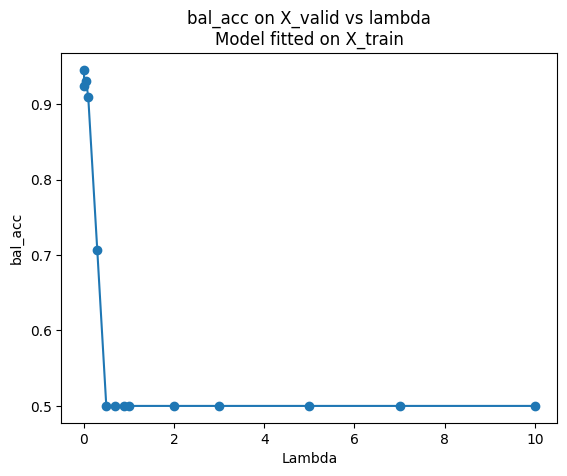

In [7]:
lr.plot("bal_acc")

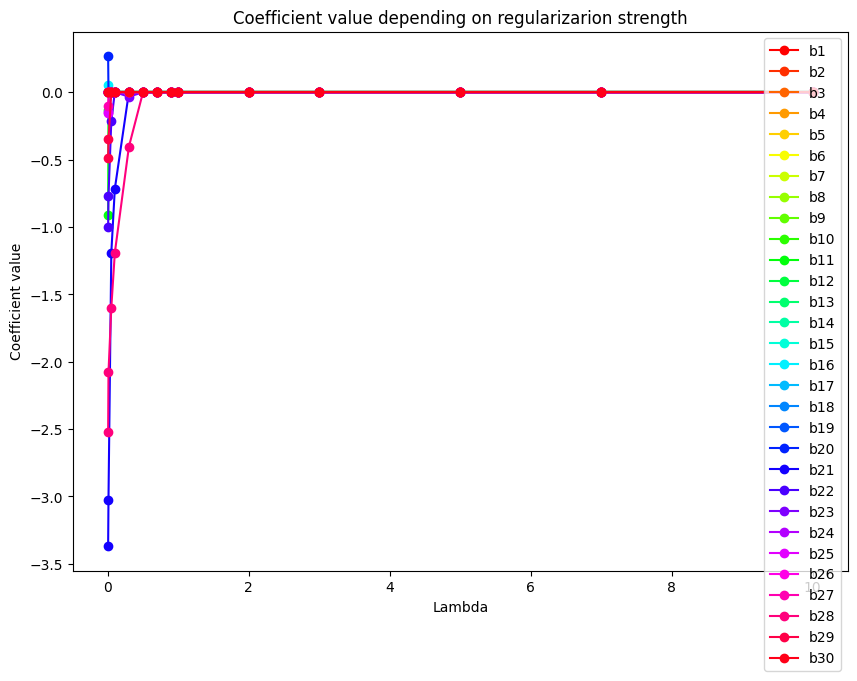

In [8]:
lr.plot_coefficients()